# Session 8, Notebook 1: The Smallest Complete PINN

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 14:00-14:55, Physics-informed neural networks: foundations
**Slides:** `08_PINNs_Foundations.pdf`
**Notebook role:** in-class walkthrough
**Author:** Simon Scheidegger (HEC, University of Lausanne)

A physics-informed neural network (PINN) is a network trained to satisfy a differential equation.
There are no labels: the residual of the equation, evaluated by automatic differentiation at a set
of collocation points, is the loss, together with a penalty for the boundary conditions. This is
the Deep Equilibrium Net idea of Day 1 with a differential operator in place of the Euler equation.

The problem is the simplest one that has every ingredient,

$$y''(x) = -1, \quad x \in (0,1), \qquad y(0) = y(1) = 0, \qquad\text{solution } y(x) = \frac{1}{2}x(1-x),$$

so every number below can be checked against the exact answer.

| Section | Content |
|:--|:--|
| 1 | The network, and why `tanh` |
| 2 | The residual $y'' + 1$ by two calls to `torch.autograd.grad` |
| 3 | Training on resampled collocation points with a boundary penalty |
| 4 | The error against the exact solution, and what it is made of |

In [1]:
SEED = 42

In [2]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(SEED); np.random.seed(SEED)
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                     "legend.fontsize": 9, "font.family": "serif", "mathtext.fontset": "cm",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
C_TRUE, C_SOFT, C_HARD = "#264653", "#e76f51", "#2a9d8f"

FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = True   # the stored run writes the figures the slides use
def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")


## 1. The network

One input, two hidden layers of 20 units, one output. The activation is `tanh`, which is smooth:
the loss needs $y''$, and a ReLU network has $y'' = 0$ almost everywhere, so a ReLU PINN for a
second-order equation receives no gradient from the residual.

In [3]:
class ODENet(nn.Module):
    """1 -> 20 -> 20 -> 1 with tanh activations."""
    def __init__(self, width=20):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, width), nn.Tanh(),
                                 nn.Linear(width, width), nn.Tanh(),
                                 nn.Linear(width, 1))
    def forward(self, x):
        return self.net(x)

model = ODENet()
print(model)
print(f"trainable parameters: {sum(p.numel() for p in model.parameters())}")

ODENet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=1, bias=True)
  )
)
trainable parameters: 481


## 2. The residual by automatic differentiation

The residual is $r(x) = y''(x) + 1$. Two calls to `torch.autograd.grad` give $y'$ and then $y''$.
`create_graph=True` is essential both times: the first call must return a differentiable $y'$ so
that it can be differentiated again, and the second must return a differentiable $y''$ so that the
training step can backpropagate through the residual to the weights.

In [4]:
def residual(model, x):
    """r(x) = y''(x) + 1 at the collocation points x, shape [N, 1]."""
    x = x.clone().requires_grad_(True)
    y = model(x)
    dy_dx = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    d2y_dx2 = torch.autograd.grad(dy_dx, x, grad_outputs=torch.ones_like(dy_dx), create_graph=True)[0]
    return d2y_dx2 + 1.0

# sanity check on a function whose second derivative we know: y = x^3 gives y'' = 6x
x_chk = torch.tensor([[0.5], [1.0]])
print("autograd check on y = x^3, r = y'' + 1 should be 6x + 1:", residual(lambda x: x**3, x_chk).ravel().tolist())

autograd check on y = x^3, r = y'' + 1 should be 6x + 1: [4.0, 7.0]


## 3. Training

The loss has two terms,

$$\mathcal{L} = \underbrace{\frac{1}{N}\sum_{i=1}^{N} r(x_i)^2}_{\text{residual}}
  \;+\; \underbrace{y_\theta(0)^2 + y_\theta(1)^2}_{\text{boundary penalty}},$$

with $N = 50$ collocation points drawn afresh from $(0,1)$ at every step, so the network never sees
the same set twice, and Adam at learning rate $10^{-3}$ for 5,000 steps. The boundary weight is
$\lambda = 1$; Notebook 2 is about what that choice costs.

In [5]:
n_colloc, n_epochs, lr = 50, 5000, 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
x_bc = torch.tensor([[0.0], [1.0]])
loss_history = []

t0 = time.time()
for epoch in range(1, n_epochs + 1):
    x_int = torch.rand(n_colloc, 1)
    loss_pde = torch.mean(residual(model, x_int) ** 2)
    loss_bc = torch.sum(model(x_bc) ** 2)
    loss = loss_pde + loss_bc
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    loss_history.append(loss.item())
    if epoch % 1000 == 0 or epoch == 1:
        print(f"epoch {epoch:5d}  loss {loss.item():.3e}  (residual {loss_pde.item():.3e}, boundary {loss_bc.item():.3e})")
print(f"training time {time.time() - t0:.0f} s")

epoch     1  loss 8.198e-01  (residual 8.065e-01, boundary 1.338e-02)


epoch  1000  loss 4.364e-05  (residual 4.353e-05, boundary 1.123e-07)


epoch  2000  loss 3.886e-05  (residual 3.876e-05, boundary 1.054e-07)


epoch  3000  loss 2.027e-05  (residual 2.021e-05, boundary 6.127e-08)


epoch  4000  loss 2.093e-05  (residual 1.987e-05, boundary 1.065e-06)


epoch  5000  loss 8.269e-06  (residual 8.002e-06, boundary 2.669e-07)
training time 8 s


## 4. The error, and what it is made of

The loss only says that the residual is small where it was sampled. The comparison with
$\frac{1}{2}x(1-x)$ says how good the solution is. The right panel shows the error itself, and it is
nearly a straight line: with $r \approx 0$ the error $e = y_\theta - y$ satisfies $e'' \approx 0$,
so $e$ is close to the linear interpolation of its two boundary values. The interior error of a
soft-boundary PINN for this equation is the boundary error, carried inside. That is what the hard
boundary conditions of Notebook 2 remove.

max |error| 6.47e-04, mean |error| 2.48e-04
error at the boundaries: y(0) = +1.46e-05, y(1) = -6.47e-04
max |error - affine interpolation of the boundary errors| = 1.15e-04


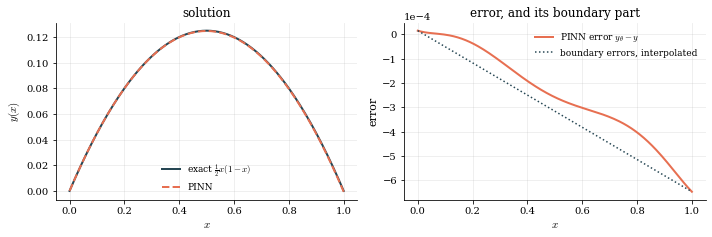

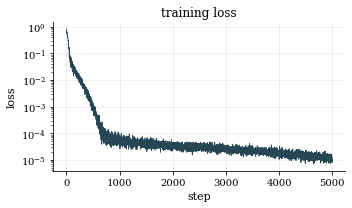

In [6]:
x_eval = torch.linspace(0, 1, 201).reshape(-1, 1)
with torch.no_grad():
    y_pred = model(x_eval).numpy().ravel()
x_np = x_eval.numpy().ravel(); y_exact = 0.5 * x_np * (1 - x_np)
err = y_pred - y_exact
e0, e1 = err[0], err[-1]
err_affine = e0 * (1 - x_np) + e1 * x_np        # what the error would be if e'' were exactly 0

print(f"max |error| {np.abs(err).max():.2e}, mean |error| {np.abs(err).mean():.2e}")
print(f"error at the boundaries: y(0) = {e0:+.2e}, y(1) = {e1:+.2e}")
print(f"max |error - affine interpolation of the boundary errors| = {np.abs(err - err_affine).max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(x_np, y_exact, color=C_TRUE, lw=2, label=r"exact $\frac{1}{2}x(1-x)$")
axes[0].plot(x_np, y_pred, "--", color=C_SOFT, lw=2, label="PINN")
axes[0].set_xlabel("$x$"); axes[0].set_ylabel("$y(x)$"); axes[0].legend(frameon=False)
axes[0].set_title("solution")
axes[1].plot(x_np, err, color=C_SOFT, lw=2, label="PINN error $y_\\theta - y$")
axes[1].plot(x_np, err_affine, ":", color=C_TRUE, lw=1.5, label="boundary errors, interpolated")
axes[1].set_xlabel("$x$"); axes[1].set_ylabel("error"); axes[1].legend(frameon=False)
axes[1].set_title("error, and its boundary part")
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
fig.tight_layout(); savefig(fig, "pinn_ode_warmup"); plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
ax.semilogy(loss_history, color=C_TRUE, lw=0.8); ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.set_title("training loss")
fig.tight_layout(); plt.show()

## Summary

* A PINN needs three things: a smooth network, the residual by `autograd`, and a loss over
  collocation points plus the boundary conditions. That is all the code above does.
* Judge it by the error against the known solution, not by the loss.
* The error of this soft-boundary run is essentially the boundary error, spread through the domain.
  Notebook 2 removes the boundary penalty altogether and adds the second stage of the optimizer.